In [1]:
%pip install -q torch torchvision scikit-learn matplotlib seaborn pillow

In [2]:

import os
import random
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cpu
Device: cpu


In [3]:
from google.colab import userdata
userdata.get('KaggleAPI')

'KGAT_8a809da7fbcb26c213f55680a7484d87'

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ashishjangra27/face-mask-12k-images-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'face-mask-12k-images-dataset' dataset.
Path to dataset files: /kaggle/input/face-mask-12k-images-dataset


In [5]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("  Number of files:", len(files))
    print("  Subfolders:", dirs)

/kaggle/input/face-mask-12k-images-dataset
  Number of files: 0
  Subfolders: ['Face Mask Dataset']
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset
  Number of files: 0
  Subfolders: ['Validation', 'Test', 'Train']
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Validation
  Number of files: 0
  Subfolders: ['WithoutMask', 'WithMask']
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Validation/WithoutMask
  Number of files: 400
  Subfolders: []
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Validation/WithMask
  Number of files: 400
  Subfolders: []
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Test
  Number of files: 0
  Subfolders: ['WithoutMask', 'WithMask']
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Test/WithoutMask
  Number of files: 509
  Subfolders: []
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Test/WithMask
  Number of files: 483
  Subfolders: []
/kaggle/input/face-mask-12k-im

In [6]:
from pathlib import Path

dataset_path = Path(path)

for p in dataset_path.rglob("*"):
    if p.is_dir():
        print(p)

/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Validation
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Test
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Validation/WithoutMask
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Validation/WithMask
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Test/WithoutMask
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Test/WithMask
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train/WithoutMask
/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train/WithMask


In [7]:
import os

BASE_DIR = "/kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "Train")
VAL_DIR   = os.path.join(BASE_DIR, "Validation")
TEST_DIR  = os.path.join(BASE_DIR, "Test")

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Train: /kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Train
Validation: /kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Validation
Test: /kaggle/input/face-mask-12k-images-dataset/Face Mask Dataset/Test


In [8]:
for name, path in [
    ("Train", TRAIN_DIR),
    ("Validation", VAL_DIR),
    ("Test", TEST_DIR)
]:
    print(f"\n{name}")

    for class_name in ["WithoutMask", "WithMask"]:
        class_path = os.path.join(path, class_name)
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        label = 0 if class_name == "WithoutMask" else 1
        print(f"{class_name} ({label}): {count}")


Train
WithoutMask (0): 5000
WithMask (1): 5000

Validation
WithoutMask (0): 400
WithMask (1): 400

Test
WithoutMask (0): 509
WithMask (1): 483


In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=["WithoutMask", "WithMask"],
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=["WithoutMask", "WithMask"],
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=["WithoutMask", "WithMask"],
    shuffle=False
)

print("Class mapping:", train_generator.class_indices)

Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Class mapping: {'WithoutMask': 0, 'WithMask': 1}


In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Load pretrained ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze ResNet layers initially
base_model.trainable = False

# Build classification model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_resnet50_mask_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [18]:
EPOCHS = 5

history = model.fit(
    train_generator,
    steps_per_epoch=50,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9924 - loss: 0.0288
Epoch 1: val_accuracy improved from None to 0.99750, saving model to best_resnet50_mask_model.keras

Epoch 1: finished saving model to best_resnet50_mask_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 412s 8s/step - accuracy: 0.9937 - loss: 0.0261 - val_accuracy: 0.9975 - val_loss: 0.0098 - learning_rate: 1.0000e-04
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9951 - loss: 0.0198
Epoch 2: val_accuracy improved from 0.99750 to 0.99875, saving model to best_resnet50_mask_model.keras

Epoch 2: finished saving model to best_resnet50_mask_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 436s 9s/step - accuracy: 0.9937 - loss: 0.0209 - val_accuracy: 0.9987 - val_loss: 0.0083 - learning_rate: 1.0000e-04
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9939 - loss: 0.0153
Epoch 3: val_accuracy did not improve from 0.99875
50/50 ━━━━━━━━━━━━━━━━━━━━ 411s 8s/step - accuracy: 0.9950 - loss: 0.0150 - val_

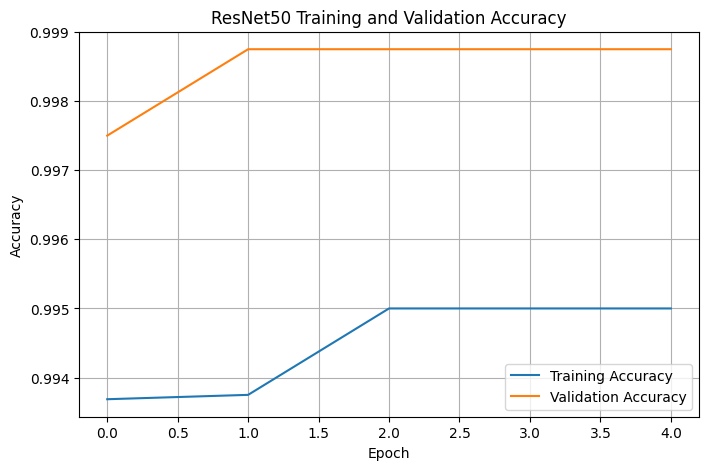

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

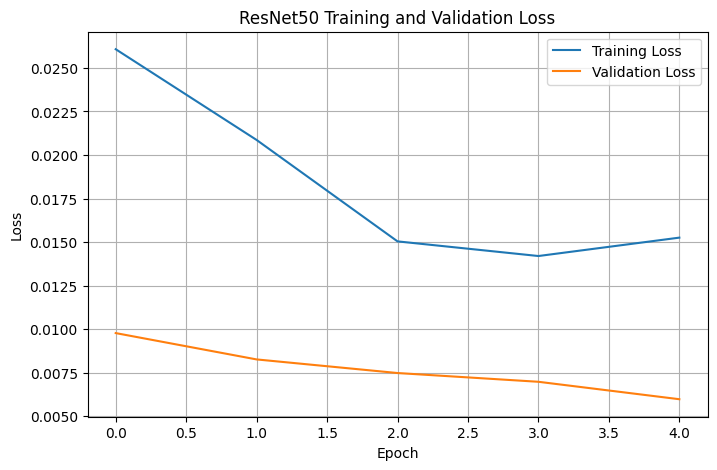

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [21]:
test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

31/31 ━━━━━━━━━━━━━━━━━━━━ 159s 5s/step - accuracy: 0.9960 - loss: 0.0140
Test Loss: 0.0140
Test Accuracy: 0.9960
Test Accuracy: 99.60%


31/31 ━━━━━━━━━━━━━━━━━━━━ 163s 5s/step
Confusion Matrix:
[[505   4]
 [  0 483]]


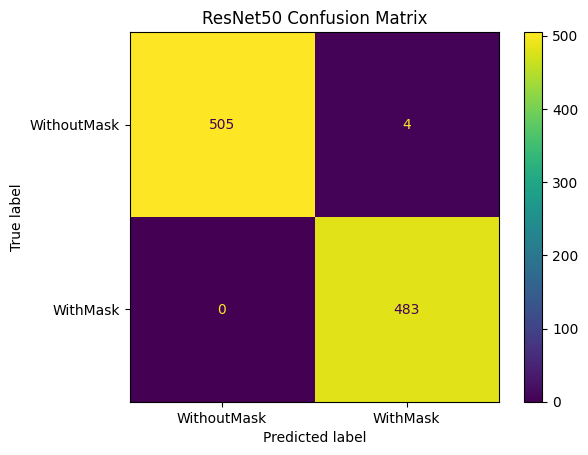

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reset generator
test_generator.reset()

# Predictions
predictions = model.predict(test_generator)

# Convert probabilities to class labels
y_pred = (predictions >= 0.5).astype(int).ravel()

# Actual labels
y_true = test_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["WithoutMask", "WithMask"]
)

disp.plot()
plt.title("ResNet50 Confusion Matrix")
plt.show()

In [23]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["WithoutMask", "WithMask"],
        digits=4
    )
)

              precision    recall  f1-score   support

 WithoutMask     1.0000    0.9921    0.9961       509
    WithMask     0.9918    1.0000    0.9959       483

    accuracy                         0.9960       992
   macro avg     0.9959    0.9961    0.9960       992
weighted avg     0.9960    0.9960    0.9960       992



1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


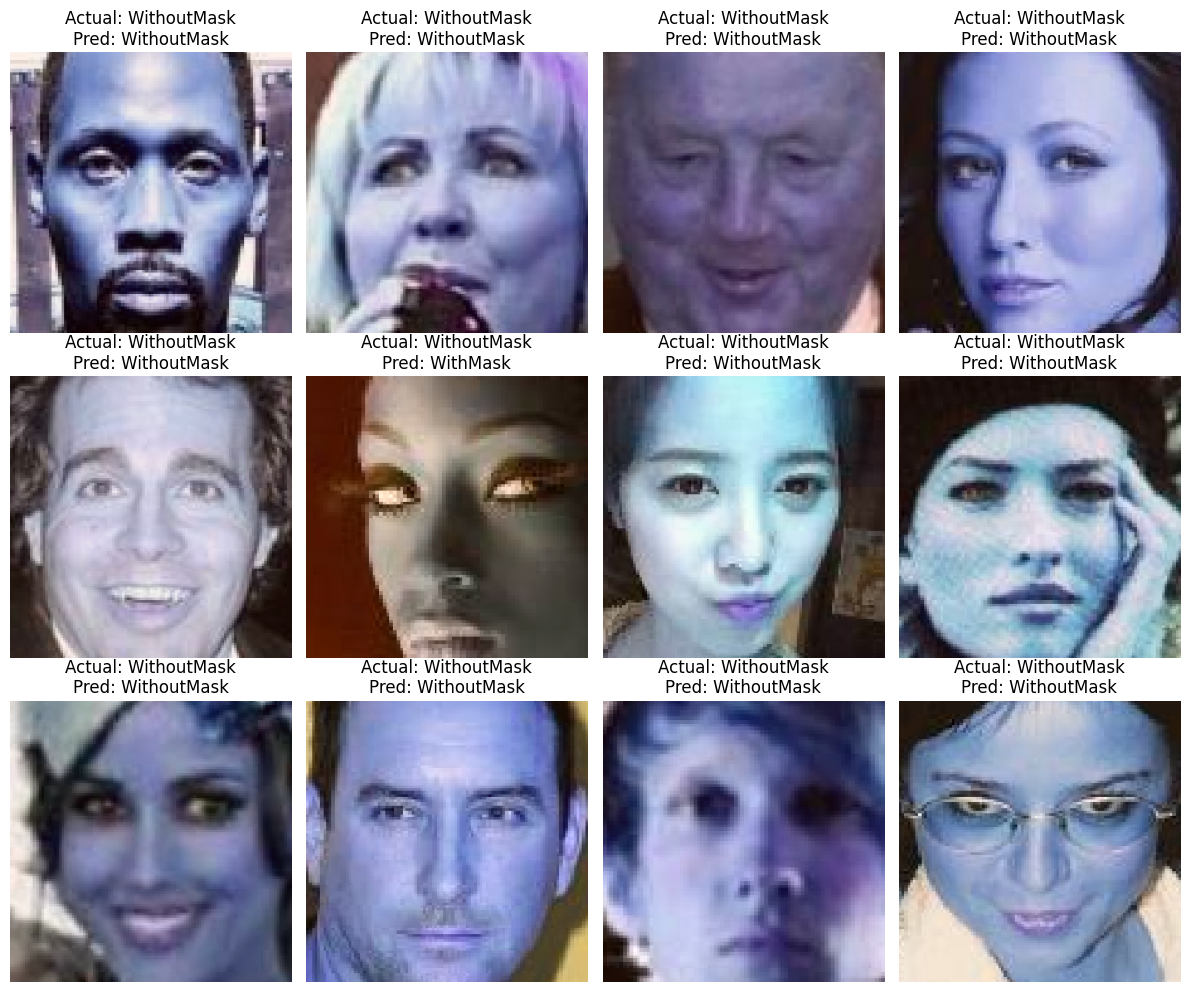

In [24]:
import numpy as np
import matplotlib.pyplot as plt

test_generator.reset()

images, labels = next(test_generator)

predictions = model.predict(images)

predicted_labels = (predictions >= 0.5).astype(int).ravel()

class_names = ["WithoutMask", "WithMask"]

plt.figure(figsize=(12, 10))

for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)

    # ResNet preprocessing reverses pixel scaling approximately
    img = images[i]
    img = img - img.min()
    img = img / img.max()

    plt.imshow(img)

    actual = class_names[int(labels[i])]
    predicted = class_names[int(predicted_labels[i])]

    if actual == predicted:
        title = f"Actual: {actual}\nPred: {predicted}"
    else:
        title = f"Actual: {actual}\nPred: {predicted}"

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
model.save("resnet50_face_mask_classifier.keras")

print("Model saved successfully!")

Model saved successfully!
